In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
!mkdir data
!unzip "/content/gdrive/MyDrive/Dataset/titanic.zip" -d "/content/data"

mkdir: cannot create directory ‘data’: File exists
Archive:  /content/gdrive/MyDrive/Dataset/titanic.zip
  inflating: /content/data/gender_submission.csv  
  inflating: /content/data/test.csv  
  inflating: /content/data/train.csv  


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import (StratifiedKFold, StratifiedShuffleSplit, 
                                     train_test_split, GridSearchCV, cross_val_score, 
                                     RandomizedSearchCV)

In [2]:
# Load the dataset
data_train = pd.read_csv('/content/data/train.csv')
data_test = pd.read_csv('/content/data/test.csv')
data_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Preprocessing

In [3]:
# Check NaN value
print("Data train NaN value : \n{}".format(data_train.isna().sum()))
print("\nData train NaN value : \n{}".format(data_test.isna().sum()))

Data train NaN value : 
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Data train NaN value : 
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


In [5]:
# Drop of some unused features 
X_train = data_train.drop(["PassengerId", "Survived", "Name", "Ticket", "Cabin", "Embarked"], axis=1)
y_train = data_train["Survived"]

X_test = data_test.drop(["PassengerId", "Name", "Ticket", "Cabin", "Embarked"], axis=1)
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,male,22.0,1,0,7.2500
1,1,female,38.0,1,0,71.2833
2,3,female,26.0,0,0,7.9250
3,1,female,35.0,1,0,53.1000
4,3,male,35.0,0,0,8.0500


#### Cleaning

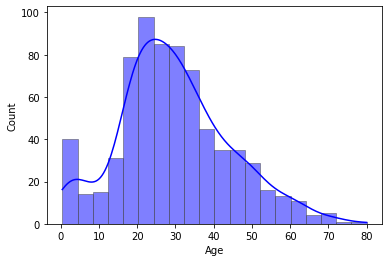

In [6]:
# Distribution of Age
sns.histplot(X_train['Age'], linewidth=.5, edgecolor=".3", kde=True, color='blue')

In [7]:
# Fill in the nan values with the average value in the age column
X_train["Age"] = X_train["Age"].fillna(X_train["Age"].mean(), axis=0)    # Age for data_train
X_test["Age"] = X_test["Age"].fillna(X_test["Age"].mean(), axis=0)    # Age for data_train

#print("Data train NaN value : \n{}".format(X_train.isna().sum()))

In [8]:
# Cleaning the nan values in the Fare column
X_test[X_test.isna().any(axis=1)]

,Pclass,Sex,Age,SibSp,Parch,Fare
152,3,male,60.5,0,0,NaN


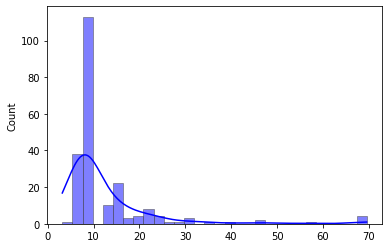

In [9]:
Fare_pclass_3 = []
for i in X_test.index:
    if (X_test['Pclass'].loc[i] == 3):
        Fare_pclass_3.append(X_test['Fare'].loc[i])

# Distribution of pclass "3"
sns.histplot(Fare_pclass_3, linewidth=.5, edgecolor=".3", kde=True, color='blue')

In [10]:
# Fill in the nan values with the median value in the Fare column
X_test["Fare"] = X_test["Fare"].fillna(np.nanmedian(Fare_pclass_3), axis=0)

print("Data train NaN value : \n{}".format(X_train.isna().sum()))
print("\nData test NaN value : \n{}".format(X_test.isna().sum()))

Data train NaN value : 
Pclass    0
Sex       0
Age       0
SibSp     0
Parch     0
Fare      0
dtype: int64

Data test NaN value : 
Pclass    0
Sex       0
Age       0
SibSp     0
Parch     0
Fare      0
dtype: int64


#### Encoding Categorical

In [11]:
# Age column
age_group_train = []
for i in X_train.index:
    if (X_train["Age"].loc[i] <= 5):
        age_group_train.append("Baby")
    elif (X_train["Age"].loc[i] <= 17):
        age_group_train.append("Children")
    elif (X_train["Age"].loc[i] <= 24):
        age_group_train.append("Youth")
    elif (X_train["Age"].loc[i] <= 50):
        age_group_train.append("Adult")
    elif (X_train["Age"].loc[i] > 50):
        age_group_train.append("Senior")
    else:
        age_group_train.append('Unknown')


age_group_test = []
for i in X_test.index:
    if (X_test["Age"].loc[i] <= 5):
        age_group_test.append("Baby")
    elif (X_test["Age"].loc[i] <= 17):
        age_group_test.append("Children")
    elif (X_test["Age"].loc[i] <= 24):
        age_group_test.append("Youth")
    elif (X_test["Age"].loc[i] <= 50):
        age_group_test.append("Adult")
    elif (X_test["Age"].loc[i] > 50):
        age_group_test.append("Senior")
    else:
        age_group_test.append('Unknown')


X_train["Age_group"] = age_group_train
X_test["Age_group"] = age_group_test

age_map = {'Baby':0, 'Children':1, 'Youth':2, 'Adult':3, 'Senior':4}
X_train['Age_group'] = X_train['Age_group'].map(age_map)
X_test['Age_group'] = X_test['Age_group'].map(age_map)

X_train['Age_group'] = X_train['Age_group'].astype('int')
X_test['Age_group'] = X_test['Age_group'].astype('int')

# Drop age column
X_train = X_train.drop(["Age"], axis=1)
X_test = X_test.drop(["Age"], axis=1)

In [12]:
# Sex column
sex_map = {'male':0, 'female':1}
X_train['Sex'] = X_train['Sex'].map(sex_map)
X_test['Sex'] = X_test['Sex'].map(sex_map)

In [13]:
# Fare column
fare_group_train = []
for i in X_train.index:
    if (X_train["Fare"].loc[i] < 100.0):
        fare_group_train.append("Middle class")
    elif (X_train["Fare"].loc[i] < 300.0):
        fare_group_train.append("Rich")
    elif (X_train["Fare"].loc[i] >= 300.0):
        fare_group_train.append("Super Rich")
    else:
        fare_group_train.append('Unknown')


fare_group_test = []
for i in X_test.index:
    if (X_test["Fare"].loc[i] < 100.0):
        fare_group_test.append("Middle class")
    elif (X_test["Fare"].loc[i] < 300.0):
        fare_group_test.append("Rich")
    elif (X_test["Fare"].loc[i] >= 300.0):
        fare_group_test.append("Super Rich")
    else:
        fare_group_test.append('Unknown')


X_train["fare_group"] = fare_group_train
X_test["fare_group"] = fare_group_test

fare_map = {'Middle class':0, 'Rich':1, 'Super Rich':2}
X_train['fare_group'] = X_train['fare_group'].map(fare_map)
X_test['fare_group'] = X_test['fare_group'].map(fare_map)

X_train = X_train.drop(["Fare"], axis=1)
X_test = X_test.drop(["Fare"], axis=1)

In [14]:
X_train.head()

,Pclass,Sex,SibSp,Parch,Age_group,fare_group
0,3,0,1,0,2,0
1,1,1,1,0,3,0
2,3,1,0,0,3,0
3,1,1,1,0,3,0
4,3,0,0,0,3,0


In [15]:
X_test.head()

,Pclass,Sex,SibSp,Parch,Age_group,fare_group
0,3,0,0,0,3,0
1,3,1,1,0,3,0
2,2,0,0,0,4,0
3,3,0,0,0,3,0
4,3,1,1,1,2,0


### Model

In [16]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, 
                                                  test_size = 0.2, random_state=0)

print("Data training : {}".format(X_train.shape))
print("Data validation : {}".format(X_val.shape))

Data training : (712, 6)
Data validation : (179, 6)


#### Hyperparameter tunning using GridSearchCv

In [18]:
# GridSearch
params_grid = dict(n_estimators=list(range(100, 500, 100)), 
                   max_features=['auto', 'sqrt', 'log2']) 

# Random forest
model = RandomForestClassifier()
cv = StratifiedKFold(n_splits=10)
grid_search = GridSearchCV(model, param_grid=params_grid, 
                           cv=cv, n_jobs=-1)

grid_search.fit(X_train, y_train)
#result = pd.DataFrame(grid_search.cv_results_)

print('Best score: {:.2f}'.format(grid_search.best_score_))
print('Best parameters: {}'.format(grid_search.best_params_))

Best score: 0.81
Best parameters: {'max_features': 'auto', 'n_estimators': 400}


In [19]:
# Random Forest
clf = RandomForestClassifier(max_features='sqrt', n_estimators=300)
clf.fit(X_train, y_train)
y_pred_val = clf.predict(X_val)

target_names = ['No', 'Yes']
print('classification report : \n', classification_report(y_val, y_pred_val, 
                                                          target_names=target_names))
print("ROC_AUC Score : {:.4f}".format(roc_auc_score(y_val, y_pred_val)))

classification report : 
               precision    recall  f1-score   support

          No       0.82      0.87      0.85       110
         Yes       0.77      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

ROC_AUC Score : 0.7842


### Submission

In [23]:
y_pred_test = clf.predict(X_test)
prediction = pd.DataFrame({'PassengerId':data_test['PassengerId'], 'Survived':y_pred_test})
prediction.to_csv('submission.csv', index=False)